In [9]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import glob
import os
from collections import defaultdict
import os
import numpy as np
import healpy as hp
from ligo.skymap.io import fits
from ligo.skymap import postprocess
import csv
from io import StringIO

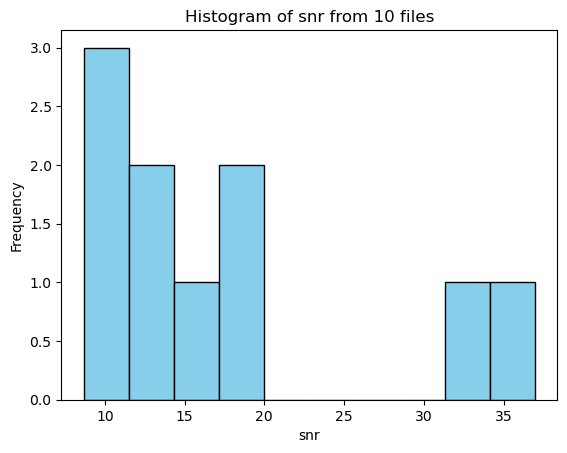

8.686093259091553


In [10]:
# Parameters
folder_path = 'output_xml_sh/the_test_ten/'    
file_pattern = 'bayestar*.xml'    
table_name = 'coinc_inspiral:table'
column_name = 'snr'

snr_values = []

for file in glob.glob(folder_path + file_pattern):
    try:
        tree = ET.parse(file)
        root = tree.getroot()

        # Find the table
        table = root.find(f".//Table[@Name='{table_name}']")
        if table is None:
            continue

        # Get column names to find the index of snr
        columns = [col.attrib['Name'] for col in table.findall('Column')]
        if column_name not in columns:
            continue
        snr_index = columns.index(column_name)

        # Read the Stream data
        stream = table.find('Stream')
        if stream is None or stream.text is None:
            continue

        # Get non-empty lines
        lines = [line for line in stream.text.strip().splitlines() if line.strip()]
        if not lines:
            continue

        # Take the first non-empty line
        first_line = lines[0]
        #values = [v.strip() for v in first_line.split(',')]
        reader = csv.reader(StringIO(first_line))
        values = next(reader)

        if snr_index < len(values) and values[snr_index]:
            snr_values.append(float(values[snr_index]))

    except ET.ParseError:
        pass
        #print(f"Skipping invalid XML file: {file}")

# Plot histogram
#bins=np.linspace(0,80,41)
plt.hist(snr_values, color='skyblue', edgecolor='black')
plt.title(f'Histogram of {column_name} from {len(snr_values)} files')
plt.xlabel(column_name)
plt.ylabel('Frequency')
plt.show()

print(np.min(snr_values))

Found 24 files


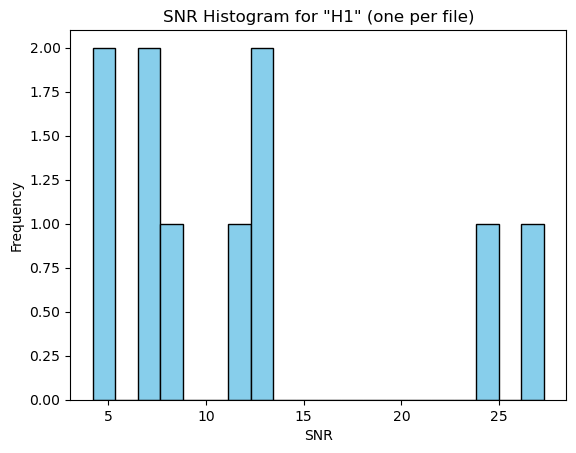

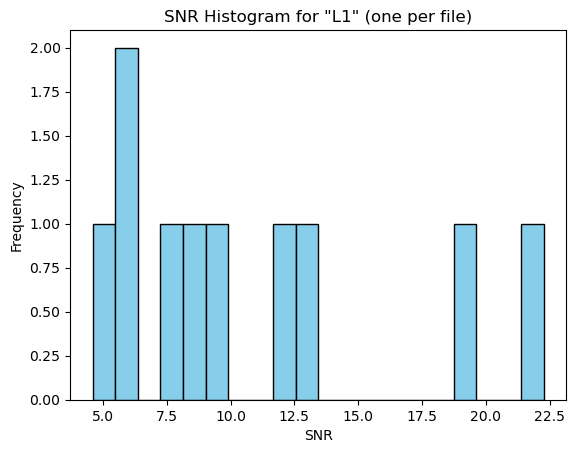

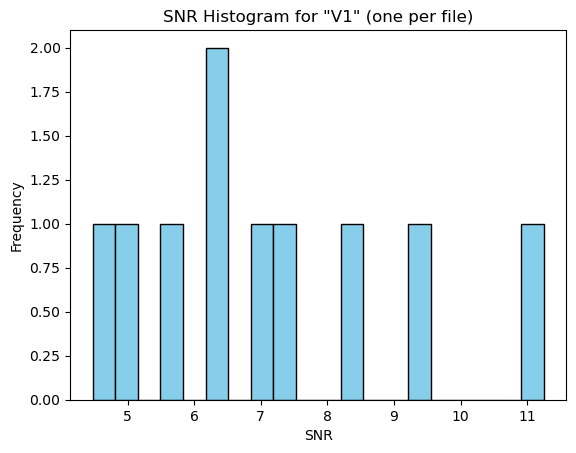

In [3]:
# Parameters
table_name = 'sngl_inspiral:table'
snr_column_name = 'snr'
ifo_column_name = 'ifo'

# Dictionary to collect first SNR per detector
snr_per_ifo = defaultdict(list)

# Find files
files = glob.glob(os.path.join(folder_path, file_pattern))
print(f"Found {len(files)} files")

for file in files:
    try:
        tree = ET.parse(file)
        root = tree.getroot()

        # Find the table
        table = root.find(f".//Table[@Name='{table_name}']")
        if table is None:
            continue

        # Get column indices
        columns = [col.attrib['Name'] for col in table.findall('Column')]
        if snr_column_name not in columns or ifo_column_name not in columns:
            continue
        snr_index = columns.index(snr_column_name)
        ifo_index = columns.index(ifo_column_name)

        # Read Stream data
        stream = table.find('Stream')
        if stream is None or not stream.text:
            continue

        # Keep track of which detectors we've already seen in this file
        seen_detectors = set()

        # Loop through non-empty lines
        for line in [l for l in stream.text.strip().splitlines() if l.strip()]:
            values = [v.strip() for v in line.split(',')]
            if snr_index >= len(values) or ifo_index >= len(values):
                continue

            snr_val = values[snr_index]
            ifo_val = values[ifo_index]

            # Skip if already added this detector
            if ifo_val in seen_detectors:
                continue

            if snr_val and ifo_val:
                snr_per_ifo[ifo_val].append(float(snr_val))
                seen_detectors.add(ifo_val)

    except ET.ParseError:
        pass
        #print(f"Skipping invalid XML file: {file}")
    except Exception as e:
        print(f"Error processing file {file}: {e}")

# Plot histograms
for ifo, snr_list in snr_per_ifo.items():
    plt.figure()
    plt.hist(snr_list, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'SNR Histogram for {ifo} (one per file)')
    #plt.xlim(0,100)
    plt.xlabel('SNR')
    plt.ylabel('Frequency')
    plt.show()

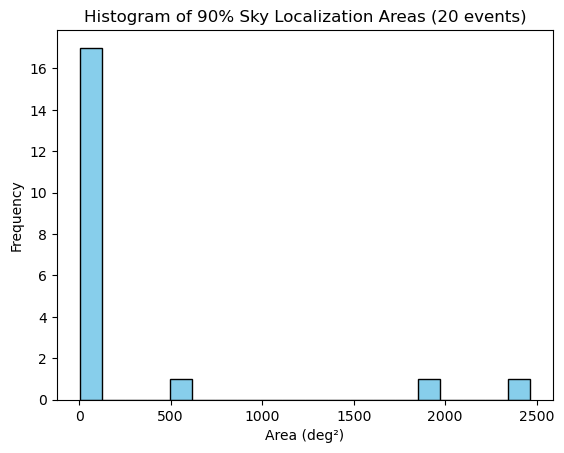

In [5]:
folder = "skymaps/the_test_ten"
contour_level = 90  # 90% credible region
area_90_list = []

for fin in os.listdir(folder):
    if fin.endswith(".fits"):
        fpath = os.path.join(folder, fin)
        
        # Read skymap
        skymap, metadata = fits.read_sky_map(fpath, nest=None)
        
        
        cls = 100 * postprocess.find_greedy_credible_levels(skymap)
        
        # Convert to area in deg2
        nside = hp.npix2nside(len(skymap))
        deg2perpix = hp.nside2pixarea(nside, degrees=True)
        cls_sorted = np.sort(cls)
        
        # Find number of pixels needed to reach contour_level
        idx = np.searchsorted(cls_sorted, contour_level)
        area_90 = int(np.round(idx * deg2perpix))  # area in deg2
        
        area_90_list.append(area_90)

# Plot histogram
plt.hist(area_90_list, bins=20, color='skyblue', edgecolor='black')
plt.title(f'Histogram of 90% Sky Localization Areas ({len(area_90_list)} events)')
plt.xlabel('Area (deg²)')
plt.ylabel('Frequency')
plt.show()